### Classification of epithelial states in Colorectal tumor-model pairs and generation of Extended Data Figure 8b, 8c.

This notebook provides an example for the analysis of COAD pairs shown in Extended Data Figure 8.

Setup user-defined parameters. Provide the full path to "HCMI_snRNAseq_data_metadata" as `Work_dir` and the full path to the current GitHub (parent) directory as `Code_dir`.

In [ ]:
cohort = "COAD"

Work_dir = "/groups/ac2248_gp/shares/hcmi/single-nuclei/HCMI_snRNAseq_data_metadata/" # parent directory for input data
Code_dir = "/groups/ac2248_gp/lz2841/ColumbiaProjects/HCMI-single-nuclei/" # path to GitHub folder

Other settings include the centroid of the reference population for data centering and scaling, the number genes to retain the reference gene expression signature (see below) and graphic parameters.

In [2]:
reference = "cells_from_tumor" # what to use as reference centroid for data centering and scaling

retain_top_genes_signature = True #
top_genes = 50 # top genes to filter for iCMS2, iCMS3
pval_NaRnEA=0.15 # above this threshold label a nucleus as "Unknown"

binary_output = False # output for the NaRnEA heatmap 
include_unknown_barplots = False # whether to include nuclei labelled as "Unknown" in the barplots

Paths to the directory collecting markers and demultiplexed input data are specified below.

In [ ]:
filtering_level_vcf = "filtered_01" # # use data from demultiplexing based on MAF>0.1%
sample_assignment = "best_gt_thresh" # according to manuscript methods


# Postprocessing filtering_level_vcf
if filtering_level_vcf == "no_filtered":
    filtering_level_vcf = ""
elif filtering_level_vcf == "filtered":
    filtering_level_vcf = "-filtered"
elif filtering_level_vcf == "filtered_01":
    filtering_level_vcf = "-filtered-01"
else:
    print("Unknown value provided for filtering_level_vcf")
    
markers_dir = f"{Code_dir}markers/" # path to directory collecting gene expression markers

Specify cases in the cohort.

In [4]:
cases=["HCM-CSHL-0143-C20", "HCM-CSHL-0322-C20", "HCM-BROD-0001-C18"]

Import packages and custom functions.

In [ ]:
import sys
import scanpy as sc
import numpy as np 
from numpy import nanmedian, NaN
import pandas as pd
import os 
from matplotlib import rc_context
import seaborn as sns
import matplotlib.pyplot as plt
import pyviper
sc.settings.verbosity = 0
sc.logging.print_header()
sc.settings.set_figure_params(frameon=False, dpi=100, facecolor="white")
from matplotlib.backends.backend_pdf import PdfPages
import hdf5plugin
import argparse
import anndata
import gc
from contextlib import contextmanager
import warnings
warnings.simplefilter("ignore", category=UserWarning)
from scipy.sparse import issparse
import re
from matplotlib.colors import LinearSegmentedColormap
from itertools import compress
from scipy.stats import combine_pvalues
from openpyxl import Workbook
sys.path.append(f'{Code_dir}funcs/')
from processing_funcs import *
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import math

import marsilea as ma
import marsilea.plotter as mp
from matplotlib.patches import Rectangle

# Custom function: retrieving putative malignant cells
def process_clusters(clusters_putative_malignant):
    # Extract the value from the Series (assuming a single element in the Series)
    cluster_value = clusters_putative_malignant.values[0]
    
    # Check if the value is "all"
    if isinstance(cluster_value, str) and cluster_value.lower() == "all":
        return cluster_value
    # If it's a comma-separated string, split it into a list of integers
    elif isinstance(cluster_value, str) and "," in cluster_value:
        return [int(i) for i in cluster_value.split(",")]
    # If it's a single integer, wrap it in a list
    else:
        return [int(cluster_value)]


# Specify other graphic parameters
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7

scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==1.24.3 scipy==1.12.0 pandas==2.2.2 scikit-learn==1.5.1 statsmodels==0.14.2 igraph==0.11.6 pynndescent==0.5.13


Load snRNA-seq metadata.

In [ ]:
snRNAseq_metadata_path = f"{Code_dir}Matched Model_Tumor for Sequencing.xlsx"
                # "Samplesheet_for_Analysis"
snRNAseq_metadata = pd.read_excel(snRNAseq_metadata_path, sheet_name="Samplesheet_for_Analysis")

Load snRNA-seq data ans subset for putative malignant cells only

In [7]:
adata_samples = {}  # initialize dictionary collecting AnnData object
samples_metadata_path = f"{Work_dir}/metadata/" # path to gene expression metadata
for case in cases:

    print(f"Case: {case}")

    case_metadata = snRNAseq_metadata[snRNAseq_metadata["Case ID"] == case] # subset for the Case ID being analyzed

    # Automatically define sample names and paths to data
    samples = [f'{case_metadata.loc[idx,"Multiplex (GEM) ID"]}_{case}' for idx in case_metadata.index] # samples names
    file_paths = {ID: f"{Work_dir}demultiplexed_samples_{sample_assignment}{filtering_level_vcf}/{ID}_gt.h5ad" for ID in samples} # path to data

    #  Load snRNA-seq metadata
    for sample, path in file_paths.items():
        # Load gene expression data and include it into AnnData object
        print('Loading ID',sample,end=' ')
        adata_samples[sample] = sc.read_h5ad(filename=path) # adata
        adata_samples[sample].var_names_make_unique()
        adata_samples[sample].obs["Sample Type"] = adata_samples[sample].obs["Sample Type"].str.rstrip() # strip spaces from Sample Type
        print(': AnnData of dimensions',adata_samples[sample].shape)
        # Subset for only the cells that previously passed QC and then only for putative malignant cells
        sample_metadata_path = f"{samples_metadata_path}{sample}-metadata.tsv"
        sample_infercnv_path = f"{samples_metadata_path}{sample}-chrs-infercnv.tsv"
        clusters_putative_malignant = case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Putative malignant clusters"]

        sample_metadata = pd.read_csv(sample_metadata_path, sep="\t")
        sample_infercnv = pd.read_csv(sample_infercnv_path, sep="\t")


        columns_to_add_metadata = sample_metadata.columns.difference(adata_samples[sample].obs.columns)
        sample_metadata = sample_metadata[columns_to_add_metadata]

        # subset for cells retained in the metadata table
        print("Subsetting only for putative tumor cells")

        cohort = list(case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Cohort"])[0]

        adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs.index.isin(sample_metadata["barcode"])]
        adata_samples[sample].obs = adata_samples[sample].obs.merge(sample_metadata, left_on='barcode', right_on="barcode", how='left') # attach metadata

        # subset of only putative malignant cells
        clusters_putative_malignant = process_clusters(clusters_putative_malignant)
        if clusters_putative_malignant != "all":
            adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["clusters"].isin(clusters_putative_malignant)]

            if cohort == "PDAC":
                adata_samples[sample].obs.set_index("barcode", inplace=True) # set index
                adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["singler_BpE_cg"] == "Epithelial cells"]

            if cohort == "COAD":
                adata_samples[sample].obs.set_index("barcode", inplace=True) # set index
                adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["singler_BpE_cg"].isin(["Epithelial cells", "Neurons"])]

        adata_samples[sample].obs.set_index("barcode", inplace=True) # set indewx
        sc.pp.calculate_qc_metrics(adata_samples[sample], qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)


    # Gene selection
    gene_names = adata_samples[sample].var_names # assume gene names are the same across all samples
    gene_counts = np.zeros(len(gene_names))
    # Iterate over each sample and accumulate the counts
    for sample, adata in adata_samples.items():
        if issparse(adata.X):
            gene_counts += np.array(adata.X.sum(axis=0)).flatten()
        else:
            gene_counts += np.sum(adata.X, axis=0)
    # Convert to DataFrame for better readability
    gene_counts_df = pd.DataFrame(data=gene_counts, index=gene_names, columns=['Total_Counts'])
    genes_retain = gene_counts_df[gene_counts_df["Total_Counts"] >= 10].index.to_list() # genes to retain 
    genes_retain = [str(gene) for gene in genes_retain]

    del gene_names, gene_counts, gene_counts_df
    gc.collect()

Case: HCM-CSHL-0143-C20
Loading ID AG001_HCM-CSHL-0143-C20 : AnnData of dimensions (1658, 38606)
Subsetting only for putative tumor cells
Loading ID AG002_HCM-CSHL-0143-C20 : AnnData of dimensions (1406, 38606)
Subsetting only for putative tumor cells
Case: HCM-CSHL-0322-C20
Loading ID AG001_HCM-CSHL-0322-C20 : AnnData of dimensions (346, 38606)
Subsetting only for putative tumor cells
Loading ID AG002_HCM-CSHL-0322-C20 : AnnData of dimensions (2552, 38606)
Subsetting only for putative tumor cells
Case: HCM-BROD-0001-C18
Loading ID AG004_HCM-BROD-0001-C18 : AnnData of dimensions (8050, 38606)
Subsetting only for putative tumor cells
Loading ID AG005_HCM-BROD-0001-C18 : AnnData of dimensions (4809, 38606)
Subsetting only for putative tumor cells


Perform gene filtering and concatenate samples

In [8]:
# Gene filtering
samples = list(adata_samples.keys())

for sample in samples:
    print(f"Gene filtering for {sample}")
    adata_samples[sample] = adata_samples[sample][:, genes_retain]


# Samples concatenation
adata_all = sc.concat(list(adata_samples.values()), axis = 0, join = 'outer') # integrate counts
adata_all.layers["counts"] = adata_all.X.copy()
adata_all.obs["Sample ID snRNAseq"] = pd.Categorical(adata_all.obs["Sample ID snRNAseq"], categories=samples, ordered=True) # order categories according to the samples list

adata_all.obs.index = adata_all.obs.index.astype(str) + "_" + adata_all.obs['Sample ID snRNAseq'].astype(str)
adata_all.obs["Case_Type"] = (adata_all.obs["Case ID"].astype(str) + " (" + adata_all.obs["Sample Type"].astype(str) + ")").str.replace("Frozen-", "", regex=False) # .obs column for plotting


del adata_samples
gc.collect()

Gene filtering for AG001_HCM-CSHL-0143-C20
Gene filtering for AG002_HCM-CSHL-0143-C20
Gene filtering for AG001_HCM-CSHL-0322-C20
Gene filtering for AG002_HCM-CSHL-0322-C20
Gene filtering for AG004_HCM-BROD-0001-C18
Gene filtering for AG005_HCM-BROD-0001-C18


12797

Data preprocessing: normalization, and scaling based on the reference signature

In [9]:
# Data preprocessing 
print("Normalizing (data); log-transforming (logdata); and scaling the data (scale) for. Setting scaled data as the defaut 'X'")
sc.pp.normalize_total(adata_all, target_sum=1e4, inplace=True) # normalize data 
sc.pp.log1p(adata_all) # logdata - log-normalization
adata_all.layers["logdata"] = adata_all.X.copy() # store logdata in the corresponding layer  


# center to specified reference 
print(f"Centering the log-transformed matrix based on {reference}")
tmp_ref = adata_all[adata_all.obs["Tumor or Model"] == "T"]
sc.pp.scale(tmp_ref, max_value=10)
mean = tmp_ref.var["mean"]
std = tmp_ref.var["std"]
del tmp_ref 
gc.collect()
adata_all.X = adata_all.X - mean.values # subtract the mean
adata_all.X = adata_all.X / std.values # divide by standard deviation 
# trim to 10
adata_all.X[adata_all.X >= 10] = 10

layer_enrichment = None # layer on which to perform the enrichment

Normalizing (data); log-transforming (logdata); and scaling the data (scale) for. Setting scaled data as the defaut 'X'
Centering the log-transformed matrix based on cells_from_tumor


Perform enrichment analysis and cell state assignment using the signatures from [Joanito et al., 2022](https://www.nature.com/articles/s41588-022-01100-4)

In [10]:
# Perform pathway enrichment analysis using NNs 
print(f"Performing pathway enrichment analysis for {sample} at the single-cell level")

Joanito_signature = pd.read_excel(f"{markers_dir}Supplementary_Tables_COAD_Joanito.xlsx", sheet_name="Supplementary Table 14")
# Transforming the dataframe into the desired format
Joanito_signature = (
    Joanito_signature.melt(var_name="regulator_mor", value_name="target")
    .dropna()
    .assign(
        regulator=lambda df: df["regulator_mor"].str.extract(r"(iCMS\d+)"),
        mor=lambda df: df["regulator_mor"].apply(lambda x: 1 if "_Up" in x else -1),
        likelihood=1
    )
    .drop(columns="regulator_mor")
)
Joanito_signature = Joanito_signature[["regulator", "target", "mor", "likelihood"]]
Joanito_signature = pyviper.Interactome('Joanito_signature', Joanito_signature) # convet to interactome

# retain top and bottom genes only
if retain_top_genes_signature == True:
    Joanito_signature.net_table = (
        Joanito_signature.net_table.groupby(["regulator", "mor"])  # Group by regulator and mor
        .apply(lambda group: group.nlargest(top_genes, "likelihood"))  # Get top 50 by likelihood
        .reset_index(drop=True)  # Reset index
    )

# compute the enrichments
Joanito_enr_nn = pyviper.tl.path_enr(adata_all, pathway_interactome=Joanito_signature, layer=layer_enrichment, enrichment="narnea", verbose=False, store_input_data=False)

Performing pathway enrichment analysis for AG005_HCM-BROD-0001-C18 at the single-cell level
Removed 13 targets.


/tmp/lz2841/ipykernel_942580/1083032212.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.nlargest(top_genes, "likelihood"))  # Get top 50 by likelihood
/users/lz2841/.conda/envs/scRNA-seq/lib/python3.11/site-packages/pyviper/NaRnEA/NaRnEA_classic.py:200: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col]

**Extended Data Figure 8b** - visualize enrichment scores and assigned cell states.

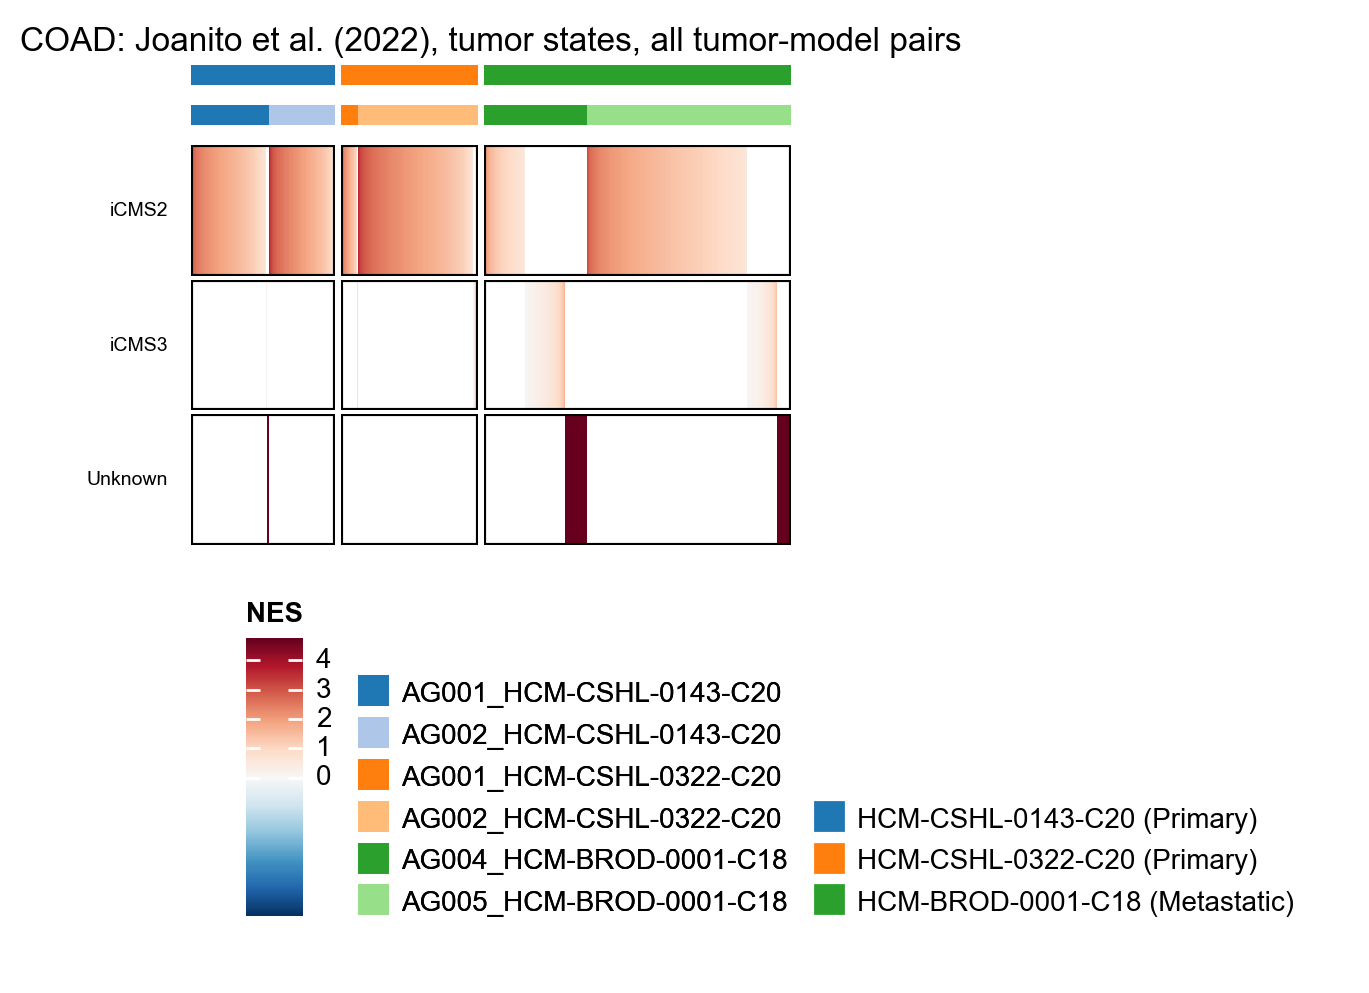

In [11]:
# Joanito t al., 2022
nes_pvals_J = pyviper._pp._nes_to_pval_df(Joanito_enr_nn.to_df(), lower_tail=False, adjust=False) # cell type which has highest P value 
Joanito_enr_nn.obs["subtype"] = nes_pvals_J.apply(get_top_cell_types, axis=1, top_n = 1, pval_threshold=1) # assign cell state with lowest P values
sorted_pathways = ["iCMS2", "iCMS3"]

Joanito_enr_nn_binary = Joanito_enr_nn.copy()
Joanito_enr_nn_binary = create_adata_to_heatmap(adata=Joanito_enr_nn_binary, subtypes=sorted_pathways, subtype_assignments=Joanito_enr_nn_binary.obs["subtype"], binary_output=binary_output)
extra_unknowns = list(np.nanmax(Joanito_enr_nn_binary.X, axis=1) < 0) # rows whose max NES is < 0
Joanito_enr_nn_binary.obs.loc[extra_unknowns,"subtype"] = "Unknown"
mask_unknown = Joanito_enr_nn_binary.obs["subtype"] == "Unknown" # set unknowns to np.nan
Joanito_enr_nn_binary.X[mask_unknown, :] = np.nan


# include Unknowns
range_min = np.nanmin(Joanito_enr_nn_binary.X)
range_max = np.nanmax(Joanito_enr_nn_binary.X)

if binary_output == True:
    unknown_val = 1
else:
    unknown_val = range_max

Joanito_enr_nn_binary.obs["Unknown"] = np.nan
mask_unknown = ~Joanito_enr_nn_binary.obs["subtype"].isin(sorted_pathways)
Joanito_enr_nn_binary.obs.loc[mask_unknown, "Unknown"] = unknown_val
 
Joanito_enr_nn_binary = sort_anndata_custom_var(Joanito_enr_nn_binary, obs_col='Sample ID snRNAseq', var_names=sorted_pathways, 
                                  ascending_order=[False, True])

title = f"{cohort}: Joanito et al. (2022), tumor states, all tumor-model pairs"        
figsize = (3, 2)  
tab20 = plt.get_cmap("tab20")

exp = Joanito_enr_nn_binary[:,sorted_pathways].X.T
unknown_values = Joanito_enr_nn_binary.obs["Unknown"].values.reshape(-1,1).T
exp = np.vstack([exp, unknown_values])

if binary_output == True:
    m = ma.Heatmap(exp, cmap="Blues", vmin=0, vmax=1, height=figsize[1], width=figsize[0], rasterized=True)  # Add label for heatmap values
else:
    m = ma.Heatmap(exp, cmap="RdBu_r", vmin=-0.01, center = 0, vmax=range_max, height=figsize[1], width=figsize[0], label="NES", rasterized=True)  # Add label for heatmap values

sorted_pathways = sorted_pathways + ["Unknown"]
# Column grouping
ordering_samples = list(Joanito_enr_nn_binary.obs["Sample ID snRNAseq"].unique())
ordering_case_types = list(Joanito_enr_nn_binary.obs["Case_Type"].unique())
m.group_cols(Joanito_enr_nn_binary.obs['Case_Type'].values, order=ordering_case_types)
m.group_rows(sorted_pathways, order=sorted_pathways)

# Plotters
#chunk = mp.Chunk(ordering_samples, rotation=90, align="center")
color_map = {cat: tab20(i) for i, cat in enumerate(ordering_samples)}
colormap_case = {cat: tab20(i*2) for i, cat in enumerate(ordering_case_types)}
colors = mp.Colors(list(Joanito_enr_nn_binary.obs['Sample ID snRNAseq']), palette=color_map)
colors_case = mp.Colors(list(Joanito_enr_nn_binary.obs['Case_Type']), palette=colormap_case)
subtypes = mp.Labels(sorted_pathways)

# Add annotations to heatmap
m.add_top(colors, size=0.1, pad=0.1)
m.add_top(colors_case, size=0.1, pad=0.1)
#m.add_top(chunk)
m.add_left(subtypes, pad=0.1)

# Legend and title
m.add_legends(side="bottom")
m.add_title(title)

m.render()
hax = m.get_main_ax()

# Add rectangles around each section
for ax in hax:
    border = Rectangle((0, 0), 1, 1, fill=False, lw=1.5, transform=ax.transAxes)
    ax.add_artist(border)

plt.show()

**Extended Data Figure 8c** - display cell states in barplots.

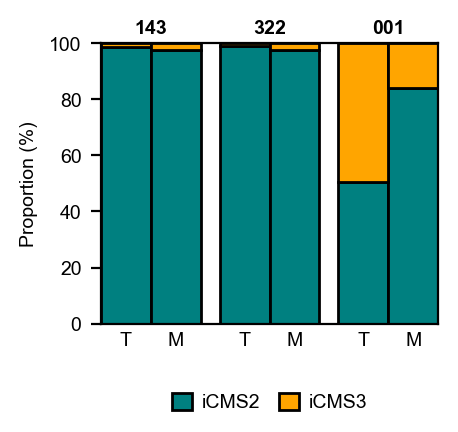

In [12]:
col_assignment = "subtype"
if include_unknown_barplots == True:
    sorted_pathways = ['iCMS2', 'iCMS3', 'Unknown'] # each attribute to plot in the radar chart
    COAD_states_colormap = {
        'iCMS2': '#008080',   # Teal
        'iCMS3': '#FFA500',   # Orange
        'Unknown': "#8c564a", # Brown
    }
elif include_unknown_barplots == False:
    sorted_pathways = ['iCMS2', 'iCMS3'] # each attribute to plot in the radar chart
    COAD_states_colormap = {
        'iCMS2': '#008080',   # Teal
        'iCMS3': '#FFA500',   # Orange
    }
num_vars = len(sorted_pathways)


# Prepare the dataframe to plot as a barplot
df_radar_all = pd.DataFrame()
n_cells_all = pd.DataFrame()
for sample in samples:
    df_radar = pd.DataFrame(Joanito_enr_nn_binary.obs.loc[Joanito_enr_nn_binary.obs["Sample ID snRNAseq"] == sample, col_assignment].value_counts()).T
    df_radar = df_radar.reindex(columns=sorted_pathways, fill_value=0)
    n_cells = pd.DataFrame({"sample": [sample], "n_cells": [df_radar.sum().sum()]})
    #df_radar = df_radar[sorted_pathways]
    df_radar.index = [sample]
    df_radar = df_radar.div(df_radar.sum(axis=1), axis=0) * 100
    df_radar_all = pd.concat([df_radar_all, df_radar])
    n_cells_all = pd.concat([n_cells_all, n_cells])

group_labels_tmp = [simplify_identifier(idx) for idx in df_radar_all.index] # group labels for plotting
# attach suffix 
counter = {}
group_labels = []
for label in group_labels_tmp:
    if label not in counter:
        counter[label] = 0
    counter[label] += 1
    # Determine suffix based on count
    if counter[label] <= 2:
        suffix = ""
    else:
        suffix = "m"
    
    # Add the updated label
    group_labels.append(f"{label}{suffix}" if label in ['078', '089'] else f"{label}")
group_labels = list(dict.fromkeys(group_labels)) # group labels for plotting


# J.2) Generate barplots
plot_grouped_stacked_bar(
    df_radar_all, 
    figsize=(2.3, 2.3), 
    title="", 
    colormap=COAD_states_colormap, 
    group_labels=group_labels, 
    group_gap=0.15, 
    tick_label_size=7,  # Adjust tick label size
    title_size=7,       # Adjust title size
    legend_size=7,      # Adjust legend size
    axis_label_size=7,  # Adjust axis label size
    n_cells_dataframe = n_cells_all, 
    #output_path=f"{barplots_path}stacked_bar_plot.pdf"  # Save the plot
)